**ETAPE 1** Import & inspection

On importe PANDAS (Analyse de données : couteau suisse de la DataScience) & NUMPY (tableaux de nombres)

In [1]:
import pandas as pd
import numpy as np

On importe le fichier

In [2]:
df = pd.read_csv('/content/drive/MyDrive/dataset_energie_batiments_pedagogique.csv')

« Une ligne = une observation
Une colonne = une variable »

On affiche les 5 premières lignes de votre tableau (votre "DataFrame").
> vérifier que les données ont été chargées correctement, à voir le nom des colonnes et à comprendre à quoi ressemblent les valeurs (est-ce du texte, des chiffres, des dates ?).

> C'est comme regarder la quatrième de couverture d'un livre ou le sommaire pour savoir de quoi il parle.
Variante : df.head(10) affichera les 10 premières lignes.

In [3]:
df.head(),
#df.info(),
#df.describe()

(   building_id  surface_m2  year_built building_type       city  \
 0            1       139.9        1994     Industrie       Lyon   
 1            2       114.5        1996     Industrie      Lille   
 2            3         NaN        1962   Résidentiel       Lyon   
 3            4       180.9        1971   Résidentiel       Lyon   
 4            5       110.6        1970   Résidentiel  Marseille   
 
    energy_consumption_kwh  co2_emissions_kg energy_class  
 0                   104.1              20.9            F  
 1                   271.8              62.3            E  
 2                   187.9              32.1            E  
 3                   144.6              35.1            A  
 4                   165.9              54.9            E  ,)

Dimensions du jeu de données :

>df.shape[0] → nombre de lignes (observations, enregistrements)

>df.shape[1] → nombre de colonnes (variables, attributs)

In [4]:
df.shape

(1200, 8)

On donne un résumé structurel de votre tableau : le nombre de lignes, le nombre de colonnes, et surtout le type de données de chaque colonne.

> détecter les problèmes techniques. Par exemple, si votre colonne "Prix" est vue comme du "Texte" (Object) au lieu d'un "Nombre" (Float), vous saurez que vous ne pourrez pas faire de calculs dessus sans la convertir. Elle indique aussi s'il manque des données (valeurs nulles).

>C'est la fiche technique d'une voiture (poids, type de moteur, nombre de places). On ne voit pas la voiture, mais on connaît ses caractéristiques.

In [5]:
#df.head(),
df.info(),
#df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   building_id             1200 non-null   int64  
 1   surface_m2              1104 non-null   float64
 2   year_built              1200 non-null   int64  
 3   building_type           1200 non-null   object 
 4   city                    1200 non-null   object 
 5   energy_consumption_kwh  1104 non-null   float64
 6   co2_emissions_kg        1104 non-null   float64
 7   energy_class            1200 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 75.1+ KB


(None,)

On calcule automatiquement des statistiques pour toutes les colonnes numériques.
> count : nombre de valeurs.

> mean : la moyenne.

> std : l'écart-type (est-ce que les prix sont très dispersés ou tous proches ?).

> min / max : les valeurs extrêmes.

>25%, 50%, 75% : les quartiles (la médiane est à 50%).


>comprendre la distribution de vos données.


>C'est le bulletin de notes d'un élève. On ne voit pas chaque copie, mais avec la moyenne, la note la plus basse et la plus haute, on connaît son niveau global.

In [6]:
df.describe()

,building_id,surface_m2,year_built,energy_consumption_kwh,co2_emissions_kg
count,1200.000000,1104.000000,1200.000000,1104.000000,1104.000000
mean,600.500000,122.013134,1985.440000,178.765036,34.624275
std,346.554469,39.047086,20.925932,58.379801,12.004656
min,1.000000,20.000000,1950.000000,40.000000,5.000000
25%,300.750000,95.725000,1968.000000,140.425000,26.900000
50%,600.500000,122.500000,1985.000000,177.400000,34.700000
75%,900.250000,147.075000,2004.000000,218.475000,42.400000
max,1200.000000,274.100000,2022.000000,338.700000,72.100000


In [7]:
df.columns = df.columns.str.lower()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   building_id             1200 non-null   int64  
 1   surface_m2              1104 non-null   float64
 2   year_built              1200 non-null   int64  
 3   building_type           1200 non-null   object 
 4   city                    1200 non-null   object 
 5   energy_consumption_kwh  1104 non-null   float64
 6   co2_emissions_kg        1104 non-null   float64
 7   energy_class            1200 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 75.1+ KB


>>> Que sait-on à ce stade ?

**ÉTAPE 2** Valeurs manquantes & qualité des données

In [8]:
df.isnull()

,building_id,surface_m2,year_built,building_type,city,energy_consumption_kwh,co2_emissions_kg,energy_class
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
1195,False,False,False,False,False,False,False,False
1196,False,False,False,False,False,False,False,False
1197,False,False,False,False,False,False,True,False
1198,False,False,False,False,False,False,False,False


« Cette commande seule ne sert à rien si on ne la synthétise pas. »

In [9]:
df.isnull().sum()

,0
building_id,0
surface_m2,96
year_built,0
building_type,0
city,0
energy_consumption_kwh,96
co2_emissions_kg,96
energy_class,0


In [10]:
df.isnull().mean() * 100

,0
building_id,0.0
surface_m2,8.0
year_built,0.0
building_type,0.0
city,0.0
energy_consumption_kwh,8.0
co2_emissions_kg,8.0
energy_class,0.0


>>> Pourquoi ces valeurs sont-elles manquantes ?

In [11]:
df[['surface_m2', 'energy_consumption_kwh', 'co2_emissions_kg']].isnull().sum()

,0
surface_m2,96
energy_consumption_kwh,96
co2_emissions_kg,96


Imputation médiane

In [12]:
df['surface_m2'] = df['surface_m2'].fillna(df['surface_m2'].median())
df['energy_consumption_kwh'] = df['energy_consumption_kwh'].fillna(df['energy_consumption_kwh'].median())
df['co2_emissions_kg'] = df['co2_emissions_kg'].fillna(df['co2_emissions_kg'].median())


Vérif post traitement

In [13]:
df.isnull().sum()

,0
building_id,0
surface_m2,0
year_built,0
building_type,0
city,0
energy_consumption_kwh,0
co2_emissions_kg,0
energy_class,0


Complétez : « Nous avons choisi d’imputer les valeurs manquantes par la médiane parce que… »

In [14]:
df.duplicated()
#df.drop_duplicates()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1195,False
1196,False
1197,False
1198,False


**Etape 3** : distributions & visualisations

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Distribution de la surface des bâtiments

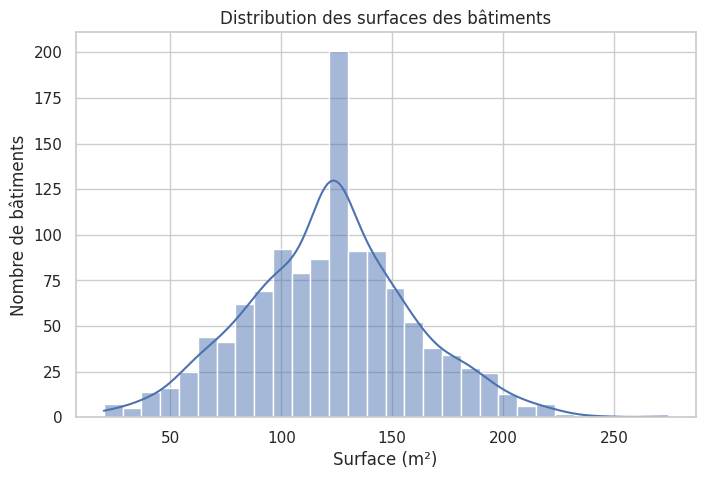

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['surface_m2'], bins=30, kde=True)
plt.title("Distribution des surfaces des bâtiments")
plt.xlabel("Surface (m²)")
plt.ylabel("Nombre de bâtiments")
plt.show()

Distribution de la consommation énergétique

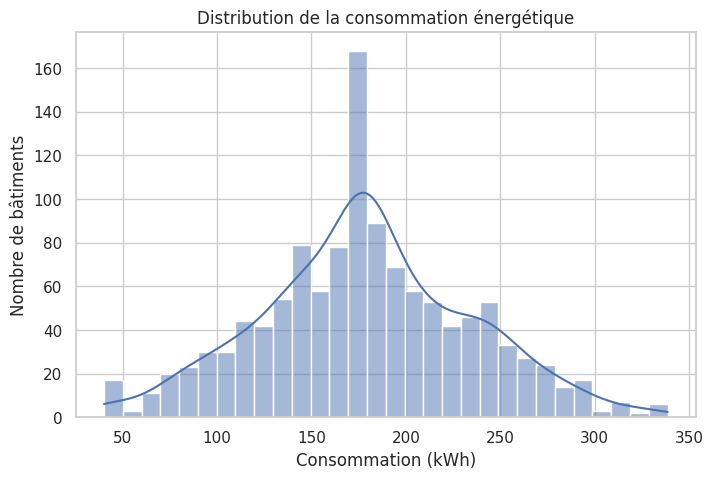

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['energy_consumption_kwh'], bins=30, kde=True)
plt.title("Distribution de la consommation énergétique")
plt.xlabel("Consommation (kWh)")
plt.ylabel("Nombre de bâtiments")
plt.show()

Détection des valeurs aberrantes

Boxplot — surface

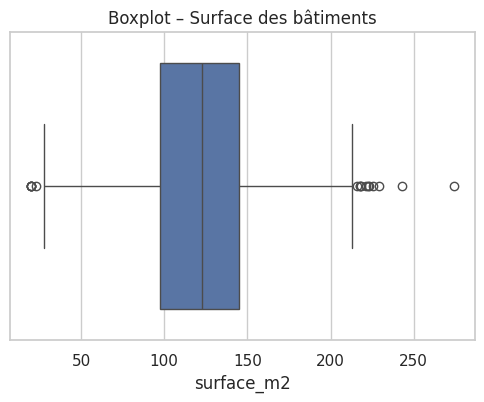

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['surface_m2'])
plt.title("Boxplot – Surface des bâtiments")
plt.show()

Boxplot — consommation

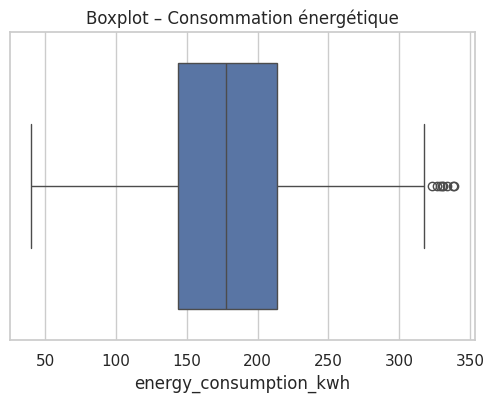

In [19]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['energy_consumption_kwh'])
plt.title("Boxplot – Consommation énergétique")
plt.show()

Relations entre variables

Surface vs consommation énergétique

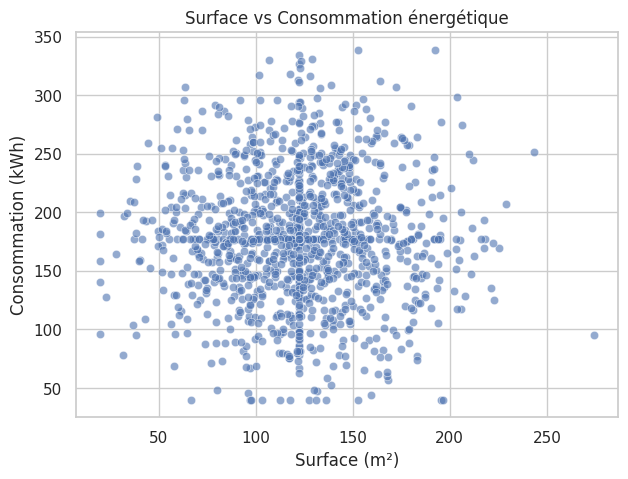

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='surface_m2',
    y='energy_consumption_kwh',
    data=df,
    alpha=0.6
)
plt.title("Surface vs Consommation énergétique")
plt.xlabel("Surface (m²)")
plt.ylabel("Consommation (kWh)")
plt.show()

Ajout d’une variable catégorielle

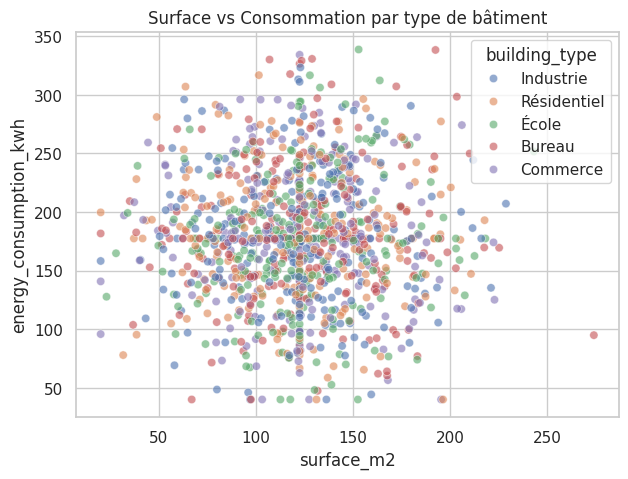

In [21]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x='surface_m2',
    y='energy_consumption_kwh',
    hue='building_type',
    data=df,
    alpha=0.6
)
plt.title("Surface vs Consommation par type de bâtiment")
plt.show()

Corrélations globales

Matrice de corrélation (numérique uniquement)

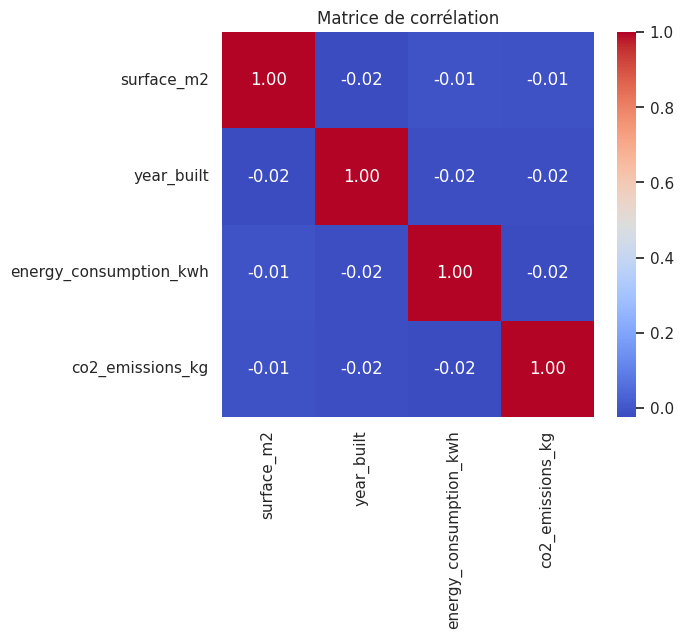

In [22]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[['surface_m2', 'year_built', 'energy_consumption_kwh', 'co2_emissions_kg']].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matrice de corrélation")
plt.show()

**Etape 4** : rapport EDA automatisé

In [23]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.3 MB/s eta 0:00:00


In [24]:
from ydata_profiling import ProfileReport

Création du rapport EDA

In [25]:
profile = ProfileReport(
    df,
    title="Rapport d'exploration — Énergie & Bâtiments",
    explorative=True
)

In [26]:
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 66.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]